<a href="https://colab.research.google.com/github/roshan-mahato/PRT_661_WILDFIRE_PREDICTION/blob/feature%2Fcomponents/Machine_Learning_Model_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fire Occurrence Model Training + Accuracy Improvement

Takes the final labelled **daily fire-weather dataset** and trains a classifier to predict whether a fire detection occurs for each grid-cell/day.

**TARGET**
- `label = 1` → qualifying fire detection
- `label = 0` → sampled no-fire cell/day

**WHY THIS IS CLASSIFICATION**
The output is fire / no-fire, so the model is trained as a binary classifier rather than trying to predict FFDI itself.

**MODEL INPUTS**
Weather + engineered fire-weather variables only. FIRMS detection fields such as brightness, FRP, confidence, satellite and instrument are not used as predictors because they would not be available before a fire is detected.

**MODEL OUTPUT**
- fire-risk score from `predict_proba()`
- binary prediction using the threshold selected on validation data

The risk score is useful for ranking / heatmap display. It is not treated as a calibrated real-world probability unless calibration is tested separately.


## 1. SETUP

Imports, random seed and output folder used by the training pipeline.


In [4]:
# ==============================================================================
# GOOGLE DRIVE
# ==============================================================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# ==============================================================================
# IMPORTS + CONFIG
# ==============================================================================
# Colab normally includes these packages; install have not
# !pip -q install xgboost lightgbm catboost imbalanced-learn shap joblib

# ---- Core Python / data ----
import os
import json
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import sys
import subprocess
import importlib.util
import platform
from importlib.metadata import version

# ---- Models / evaluation ----
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve
)

import xgboost as xgb
import lightgbm as lgb

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, log_loss

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from catboost import CatBoostClassifier
import shap

# Keep the added checks reasonably fast in Colab
CV_FOLDS = 3
CV_MAX_ROWS = 25000
SHAP_ROWS = 100
SHAP_BACKGROUND_ROWS = 50

# ---- Reproducibility + output folder ----
RANDOM_STATE = 42
OUT_DIR = Path('/content/drive/MyDrive/fire_model_outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. LOAD TRAINING DATA

Loads the labelled daily dataframe produced by the preprocessing + fire-weather feature pipeline.


In [6]:
# ==============================================================================
# LOAD LABELLED DAILY DATA
# ==============================================================================
# ---- 1. Mount Drive if needed ----
from pathlib import Path

if not Path('/content/drive/MyDrive').exists():
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print("Google Drive is already mounted.")

# ---- 2. Final labelled dataset from preprocessing ----
FINAL_CSV = '/content/drive/MyDrive/firms_weather_cleaned_with_negatives.csv'

assert Path(FINAL_CSV).exists(), (
    f'File not found: {FINAL_CSV}'
)

print('Loading:', FINAL_CSV)

# ---- 3. Load one row per grid-cell/day ----
df = pd.read_csv(FINAL_CSV)

print('Raw modelling dataframe shape:', df.shape)
display(df.head())

Google Drive is already mounted.
Loading: /content/drive/MyDrive/firms_weather_cleaned_with_negatives.csv
Raw modelling dataframe shape: (209793, 22)


,lat_round,lon_round,acq_date,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_gusts_10m,wind_direction_10m,precipitation,soil_moisture_0_to_7cm,...,label,weather_outlier_flag,kbdi,drought_factor,days_since_rain,days_since_cell_start,kbdi_spinup_flag,emc,ffdi,rate_of_spread
0,-43.5,146.0,2024-05-10,12.410222,81.477038,8.248152,17.655999,105.361071,0.0,0.229356,...,1,False,0.201304,5.654105,1.0,0.0,True,18.280370,0.782331,0.007510
1,-43.5,146.0,2024-10-21,15.752474,79.673112,9.709290,22.727368,179.126520,0.0,0.243211,...,1,False,73.937803,9.655148,165.0,164.0,False,17.448899,1.635698,0.015703
2,-43.5,146.0,2025-08-11,10.022000,72.773119,8.766971,20.448000,98.059778,0.0,0.242200,...,1,False,96.476722,10.000000,459.0,458.0,False,15.113268,1.731550,0.016623
3,-43.5,146.5,2024-11-11,8.808064,63.002205,11.854714,36.350769,222.728996,0.0,0.254949,...,1,False,0.020848,5.644313,1.0,0.0,True,12.512804,1.423095,0.013662
4,-43.5,146.5,2025-03-19,15.729990,57.477324,7.872270,31.305305,162.541743,0.0,0.273673,...,1,True,46.211935,8.150704,129.0,128.0,False,11.355945,2.848787,0.027348


## 3. TARGET + DATA CHECKS

Checks the binary target, valid dates and KBDI spin-up rows before model training and duplicate grid-cell/day records before training models.


In [7]:
# ==============================================================================
# TARGET + DATA VALIDATION
# ==============================================================================
# ---- 1. Validate binary target ----
assert 'label' in df.columns, "Target column 'label' is missing"

df['label'] = pd.to_numeric(df['label'], errors='coerce')
df = df[df['label'].isin([0, 1])].copy()
df['label'] = df['label'].astype(int)

assert set(df['label'].unique()) == {0, 1}, 'Both fire (1) and no-fire (0) rows are required'

# ---- 2. Parse / validate acquisition date ----
if 'acq_date' in df.columns:
    df['acq_date'] = pd.to_datetime(df['acq_date'], errors='coerce')
    df = df[df['acq_date'].notna()].copy()

# ---- 3. Remove early KBDI cold-start rows ----
if 'kbdi_spinup_flag' in df.columns:
    spinup = df['kbdi_spinup_flag']
    if spinup.dtype != bool:
        spinup = spinup.astype(str).str.lower().eq('true')
    df = df[~spinup].copy()

# ---- 4. Check class balance after filtering ----
class_counts = df['label'].value_counts().sort_index()
class_summary = pd.DataFrame({
    'class': ['No fire (0)', 'Fire (1)'],
    'rows': [class_counts.get(0, 0), class_counts.get(1, 0)]
})
class_summary['percent'] = 100 * class_summary['rows'] / class_summary['rows'].sum()

display(class_summary)
print('Rows after validation:', len(df))
if 'acq_date' in df.columns:
    print('Date range:', df['acq_date'].min(), 'to', df['acq_date'].max())


,class,rows,percent
0,No fire (0),66981,34.022441
1,Fire (1),129892,65.977559


Rows after validation: 196873
Date range: 2024-01-31 00:00:00 to 2026-08-25 00:00:00


In [8]:
# A duplicate cell/day could appear in more than one split and make results too optimistic
duplicate_cell_days = int(df.duplicated(['lat_round', 'lon_round', 'acq_date']).sum())
print('Duplicate grid-cell/day rows:', duplicate_cell_days)

assert duplicate_cell_days == 0, (
    'Duplicate grid-cell/day rows found. Resolve these in the preprocessing pipeline before modelling.'
)

assert df['label'].value_counts().min() >= 30, (
    'Too few observations in one class for stratified splitting and SMOTE.'
)

Duplicate grid-cell/day rows: 0


## 4. MODEL FEATURES

Builds the deployable predictor set.

FIRMS detection-only fields are excluded. `days_since_cell_start` and `rate_of_spread` are also left out, while seasonal and wind direction variables are converted to cyclical features.


In [9]:
# ==============================================================================
# BUILD MODEL FEATURES
# ==============================================================================
assert 'acq_date' in df.columns, 'acq_date is required to create seasonal features'

# ---- 1. Seasonal features ----
df['day_of_year'] = df['acq_date'].dt.dayofyear
df['month'] = df['acq_date'].dt.month

df['day_of_year_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
df['day_of_year_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# ---- 2. Wind direction is circular: 359° and 1° should stay close ----
wind_rad = np.deg2rad(df['wind_direction_10m'])
df['wind_direction_sin'] = np.sin(wind_rad)
df['wind_direction_cos'] = np.cos(wind_rad)

# ---- 3. Predictors available to the model ----
FEATURES = [
    'lat_round', 'lon_round',
    'temperature_2m', 'relative_humidity_2m',
    'wind_speed_10m', 'wind_gusts_10m',
    'wind_direction_sin', 'wind_direction_cos',
    'precipitation', 'soil_moisture_0_to_7cm',
    'vapour_pressure_deficit', 'et0_fao_evapotranspiration',
    'kbdi', 'drought_factor', 'days_since_rain', 'emc', 'ffdi',
    'day_of_year_sin', 'day_of_year_cos', 'month_sin', 'month_cos'
]

missing_features = [c for c in FEATURES if c not in df.columns]
assert not missing_features, f'Missing required model features: {missing_features}'

# ---- 4. Block FIRMS detection-only leakage ----
FIRMS_ONLY_FIELDS = {
    'brightness', 'bright_ti4', 'bright_ti5', 'frp', 'confidence', 'type',
    'satellite', 'instrument', 'scan', 'track', 'acq_time'
}
assert not (set(FEATURES) & FIRMS_ONLY_FIELDS), 'A FIRMS-only field has leaked into the predictor list.'

# ---- 5. Final X / y ----
X = df[FEATURES].copy()
y = df['label'].copy()

print('Number of model features:', len(FEATURES))
print(FEATURES)


Number of model features: 21
['lat_round', 'lon_round', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'wind_gusts_10m', 'wind_direction_sin', 'wind_direction_cos', 'precipitation', 'soil_moisture_0_to_7cm', 'vapour_pressure_deficit', 'et0_fao_evapotranspiration', 'kbdi', 'drought_factor', 'days_since_rain', 'emc', 'ffdi', 'day_of_year_sin', 'day_of_year_cos', 'month_sin', 'month_cos']


## 5. TRAIN / VALIDATION / TEST SPLIT

60% training, 20% validation, 20% test.

The split is stratified so the fire/no-fire ratio stays similar in all three sets. Validation is used for model and threshold selection; test data stays untouched until the final check. The split indices are also checked to make sure no rows overlap.

In [10]:
# ==============================================================================
# STRATIFIED DATA SPLIT
# ==============================================================================
# 60% train, 40% temporary holdout
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.40,
    stratify=y,
    random_state=RANDOM_STATE
)

# Split the remaining 40% evenly -> 20% validation / 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

for name, yy in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    print(f'{name}: {len(yy):,} rows | fire rate = {yy.mean():.2%}')


Train: 118,123 rows | fire rate = 65.98%
Validation: 39,375 rows | fire rate = 65.98%
Test: 39,375 rows | fire rate = 65.98%


In [11]:
# ==============================================================================
# SPLIT CHECKS
# ==============================================================================
assert set(X_train.index).isdisjoint(X_val.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_val.index).isdisjoint(X_test.index)

split_records = df[['acq_date', 'lat_round', 'lon_round', 'label']].copy()
split_records['split'] = ''

for split_name, indices in [
    ('train', X_train.index),
    ('validation', X_val.index),
    ('test', X_test.index)
]:
    split_records.loc[indices, 'split'] = split_name

split_records.to_csv(OUT_DIR / 'split_membership.csv', index_label='source_row')
print('Split overlap check passed.')

Split overlap check passed.


## 6. MODEL DEFINITIONS

Models compared:
- Dummy baseline
- Logistic Regression
- Decision Tree
- Random Forest
- Extra Trees
- HistGradientBoosting
- XGBoost
- LightGBM
- CatBoost

Class weighting is used where supported. Logistic Regression and Random Forest are also checked with unweighted and SMOTE alternatives so the imbalance strategy can be compared separately.


In [12]:
# ==============================================================================
# DEFINE CANDIDATE MODELS
# ==============================================================================
# Class ratio used by XGBoost; the other models use class_weight='balanced'
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / positive_count

# Candidate classifiers
models = {
    'Dummy': DummyClassifier(strategy='prior', random_state=RANDOM_STATE),

    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            class_weight='balanced',
            max_iter=2000,
            random_state=RANDOM_STATE
        ))
    ]),

    'Random Forest': RandomForestClassifier(
        n_estimators=150,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    'XGBoost': xgb.XGBClassifier(
        n_estimators=250,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.9,
        scale_pos_weight=scale_pos_weight,
        eval_metric='auc',
        tree_method='hist',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    'LightGBM': lgb.LGBMClassifier(
        n_estimators=250,
        num_leaves=31,
        learning_rate=0.05,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1
    )
}

models.update({
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced',
        max_depth=12,
        min_samples_leaf=10,
        random_state=RANDOM_STATE
    ),

    'Extra Trees': ExtraTreesClassifier(
        n_estimators=150,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    'HistGradientBoosting': HistGradientBoostingClassifier(
        max_iter=250,
        learning_rate=0.05,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ),

    'CatBoost': CatBoostClassifier(
        iterations=250,
        depth=6,
        learning_rate=0.05,
        auto_class_weights='Balanced',
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False
    )
})

real_classifier_names = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Extra Trees',
    'HistGradientBoosting',
    'XGBoost',
    'LightGBM',
    'CatBoost'
]

print('Classifier families:', real_classifier_names)

Classifier families: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Extra Trees', 'HistGradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost']


## 7. EVALUATION + CROSS-VALIDATION

Metrics used: Accuracy, Balanced Accuracy, Precision, Recall, F1, ROC-AUC and PR-AUC.

The decision threshold is selected from validation data only. Stratified cross-validation is also used on the training data to compare the eight classifier families before the normal validation/test workflow.

For runtime efficiency, the 3-fold classifier benchmark uses a 25,000-row stratified subset of the training data, while final candidate models are fitted using the full training split.

In [13]:
# ==============================================================================
# METRICS + THRESHOLD HELPERS
# ==============================================================================
def choose_threshold(y_true, scores):
    """Choose the validation threshold that maximises TPR - FPR."""
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    best_index = np.argmax(tpr - fpr)
    return float(thresholds[best_index])


def evaluate_scores(y_true, scores, threshold):
    """Return classification metrics at one decision threshold."""
    pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()

    return {
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, pred),
        'precision_fire': precision_score(y_true, pred, zero_division=0),
        'recall_fire': recall_score(y_true, pred, zero_division=0),
        'f1_fire': f1_score(y_true, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, scores),
        'pr_auc': average_precision_score(y_true, scores),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)
    }

# Matching unweighted controls
logistic_unweighted = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight=None,
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

rf_unweighted = RandomForestClassifier(
    n_estimators=150,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight=None,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# SMOTE is applied only to the training data inside the pipeline
logistic_smote = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ('model', LogisticRegression(
        class_weight=None,
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

rf_smote = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ('model', RandomForestClassifier(
        n_estimators=150,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight=None,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

imbalance_models = {
    'Logistic Regression - unweighted': logistic_unweighted,
    'Logistic Regression - class weight': clone(models['Logistic Regression']),
    'Logistic Regression - SMOTE': logistic_smote,
    'Random Forest - unweighted': rf_unweighted,
    'Random Forest - class weight': clone(models['Random Forest']),
    'Random Forest - SMOTE': rf_smote
}

imbalance_rows = []

for name, model in imbalance_models.items():
    print('Imbalance check:', name)
    model.fit(X_train, y_train)
    scores = model.predict_proba(X_val)[:, 1]
    row = evaluate_scores(y_val, scores, 0.50)
    row['model'] = name
    imbalance_rows.append(row)

imbalance_results = pd.DataFrame(imbalance_rows).sort_values(
    ['balanced_accuracy', 'roc_auc'], ascending=False
).reset_index(drop=True)

display(imbalance_results.round(4))
imbalance_results.to_csv(OUT_DIR / 'imbalance_handling_comparison.csv', index=False)

print('Training class counts:')
print(y_train.value_counts().sort_index())

if CV_MAX_ROWS is not None and len(X_train) > CV_MAX_ROWS:
    X_cv, _, y_cv, _ = train_test_split(
        X_train,
        y_train,
        train_size=CV_MAX_ROWS,
        stratify=y_train,
        random_state=RANDOM_STATE
    )
else:
    X_cv, y_cv = X_train, y_train

cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    'roc_auc': 'roc_auc',
    'average_precision': 'average_precision',
    'balanced_accuracy': 'balanced_accuracy',
    'accuracy': 'accuracy',
    'f1': 'f1'
}

cv_rows = []
cv_fold_rows = []

for name in real_classifier_names:
    model = clone(models[name])
    print('Cross-validation:', name, '| rows:', len(X_cv))

    scores = cross_validate(
        model,
        X_cv,
        y_cv,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        error_score='raise'
    )

    row = {
        'model': name,
        'cv_rows': len(X_cv),
        'folds': CV_FOLDS
    }

    for metric in scoring:
        values = scores['test_' + metric]
        row[metric + '_mean'] = float(values.mean())
        row[metric + '_sd'] = float(values.std(ddof=1))

    cv_rows.append(row)

    for fold in range(CV_FOLDS):
        cv_fold_rows.append({
            'model': name,
            'fold': fold + 1,
            **{
                metric: float(scores['test_' + metric][fold])
                for metric in scoring
            }
        })

cv_results = pd.DataFrame(cv_rows).sort_values(
    'roc_auc_mean', ascending=False
).reset_index(drop=True)

display(cv_results.round(4))

cv_results.to_csv(
    OUT_DIR / 'cross_validation_summary.csv',
    index=False
)

pd.DataFrame(cv_fold_rows).to_csv(
    OUT_DIR / 'cross_validation_folds.csv',
    index=False
)

Imbalance check: Logistic Regression - unweighted
Imbalance check: Logistic Regression - class weight
Imbalance check: Logistic Regression - SMOTE
Imbalance check: Random Forest - unweighted
Imbalance check: Random Forest - class weight
Imbalance check: Random Forest - SMOTE


,threshold,accuracy,balanced_accuracy,precision_fire,recall_fire,f1_fire,roc_auc,pr_auc,tn,fp,fn,tp,model
0,0.5,0.8383,0.8381,0.9092,0.8387,0.8725,0.9245,0.9647,11219,2177,4191,21788,Random Forest - SMOTE
1,0.5,0.8411,0.8321,0.8949,0.8601,0.8772,0.9252,0.9651,10772,2624,3634,22345,Random Forest - class weight
2,0.5,0.8385,0.8217,0.8801,0.8744,0.8772,0.9254,0.9652,10301,3095,3263,22716,Random Forest - unweighted
3,0.5,0.6864,0.7142,0.8595,0.6272,0.7252,0.7653,0.8874,10732,2664,9684,16295,Logistic Regression - class weight
4,0.5,0.6866,0.7137,0.8583,0.6289,0.7259,0.7654,0.8872,10698,2698,9642,16337,Logistic Regression - SMOTE
5,0.5,0.6967,0.6362,0.7432,0.8254,0.7822,0.7686,0.8861,5989,7407,4537,21442,Logistic Regression - unweighted


Training class counts:
label
0    40188
1    77935
Name: count, dtype: int64
Cross-validation: Logistic Regression | rows: 25000
Cross-validation: Decision Tree | rows: 25000
Cross-validation: Random Forest | rows: 25000
Cross-validation: Extra Trees | rows: 25000
Cross-validation: HistGradientBoosting | rows: 25000
Cross-validation: XGBoost | rows: 25000
Cross-validation: LightGBM | rows: 25000
Cross-validation: CatBoost | rows: 25000


,model,cv_rows,folds,roc_auc_mean,roc_auc_sd,average_precision_mean,average_precision_sd,balanced_accuracy_mean,balanced_accuracy_sd,accuracy_mean,accuracy_sd,f1_mean,f1_sd
0,LightGBM,25000,3,0.9042,0.0039,0.9559,0.0020,0.8351,0.0059,0.8100,0.0065,0.8400,0.0060
1,XGBoost,25000,3,0.9038,0.0030,0.9556,0.0015,0.8324,0.0057,0.8069,0.0054,0.8372,0.0047
2,HistGradientBoosting,25000,3,0.9038,0.0028,0.9555,0.0016,0.8341,0.0044,0.8089,0.0039,0.8391,0.0034
3,CatBoost,25000,3,0.9028,0.0023,0.9555,0.0012,0.8352,0.0046,0.8033,0.0056,0.8314,0.0054
4,Random Forest,25000,3,0.8991,0.0024,0.9526,0.0011,0.7938,0.0063,0.8121,0.0044,0.8567,0.0029
5,Extra Trees,25000,3,0.8884,0.0010,0.9456,0.0007,0.7923,0.0059,0.8041,0.0041,0.8481,0.0028
6,Decision Tree,25000,3,0.8498,0.0017,0.9150,0.0037,0.7892,0.0040,0.7665,0.0027,0.8023,0.0029
7,Logistic Regression,25000,3,0.7693,0.0010,0.8896,0.0003,0.7181,0.0040,0.6896,0.0026,0.7277,0.0017


## 8. TRAIN + VALIDATE

Fits every model on the training split, selects its validation threshold and stores the validation metrics for comparison.


In [14]:
# ==============================================================================
# TRAIN + VALIDATION COMPARISON
# ==============================================================================
fitted_models = {}
validation_rows = []

# Fit on train only; threshold + metrics come from validation only
for name, model in models.items():
    print('Training:', name)
    model.fit(X_train, y_train)
    fitted_models[name] = model

    val_scores = model.predict_proba(X_val)[:, 1]

    if name == 'Dummy':
        threshold = 0.50
    else:
        threshold = choose_threshold(y_val, val_scores)

    row = evaluate_scores(y_val, val_scores, threshold)
    row['model'] = name
    validation_rows.append(row)

# Rank by balanced accuracy first, then ROC-AUC
validation_results = pd.DataFrame(validation_rows).sort_values(
    ['balanced_accuracy', 'roc_auc'], ascending=False
).reset_index(drop=True)

display(validation_results.round(4))
validation_results.to_csv(OUT_DIR / 'validation_model_comparison.csv', index=False)


Training: Dummy
Training: Logistic Regression
Training: Random Forest
Training: XGBoost
Training: LightGBM
Training: Decision Tree
Training: Extra Trees
Training: HistGradientBoosting
Training: CatBoost


,threshold,accuracy,balanced_accuracy,precision_fire,recall_fire,f1_fire,roc_auc,pr_auc,tn,fp,fn,tp,model
0,0.6299,0.8239,0.8526,0.9624,0.7629,0.8511,0.9252,0.9651,12622,774,6160,19819,Random Forest
1,0.4837,0.8205,0.8512,0.9652,0.7552,0.8474,0.9170,0.9620,12689,707,6360,19619,LightGBM
2,0.4866,0.8162,0.8489,0.9673,0.7467,0.8428,0.9167,0.9618,12740,656,6581,19398,XGBoost
3,0.4540,0.8238,0.8488,0.9535,0.7705,0.8523,0.9161,0.9615,12420,976,5962,20017,HistGradientBoosting
4,0.4817,0.8158,0.8482,0.9662,0.7470,0.8426,0.9121,0.9600,12718,678,6573,19406,CatBoost
5,0.5876,0.8146,0.8398,0.9478,0.7609,0.8441,0.9173,0.9602,12308,1088,6212,19767,Extra Trees
6,0.5077,0.7615,0.8063,0.9603,0.6660,0.7865,0.8768,0.9337,12681,715,8677,17302,Decision Tree
7,0.5636,0.6694,0.7201,0.8998,0.5615,0.6915,0.7653,0.8874,11772,1624,11392,14587,Logistic Regression
8,0.5000,0.6598,0.5000,0.6598,1.0000,0.7950,0.5000,0.6598,0,13396,0,25979,Dummy


## 9. THRESHOLD + CALIBRATION CHECK

Compares the default `0.50` threshold with the validation-selected threshold, then checks the precision/recall trade-off and how closely the leading model scores line up with the observed validation outcomes.


,model,balanced_accuracy_at_0.50,balanced_accuracy_tuned,f1_at_0.50,f1_tuned,selected_threshold
1,Random Forest,0.8321,0.8526,0.8772,0.8511,0.6299
3,LightGBM,0.8506,0.8512,0.8433,0.8474,0.4837
2,XGBoost,0.8481,0.8489,0.8392,0.8428,0.4866
6,HistGradientBoosting,0.8481,0.8488,0.8410,0.8523,0.4540
7,CatBoost,0.8477,0.8482,0.8374,0.8426,0.4817
5,Extra Trees,0.8271,0.8398,0.8675,0.8441,0.5876
4,Decision Tree,0.8062,0.8063,0.7867,0.7865,0.5077
0,Logistic Regression,0.7142,0.7201,0.7252,0.6915,0.5636


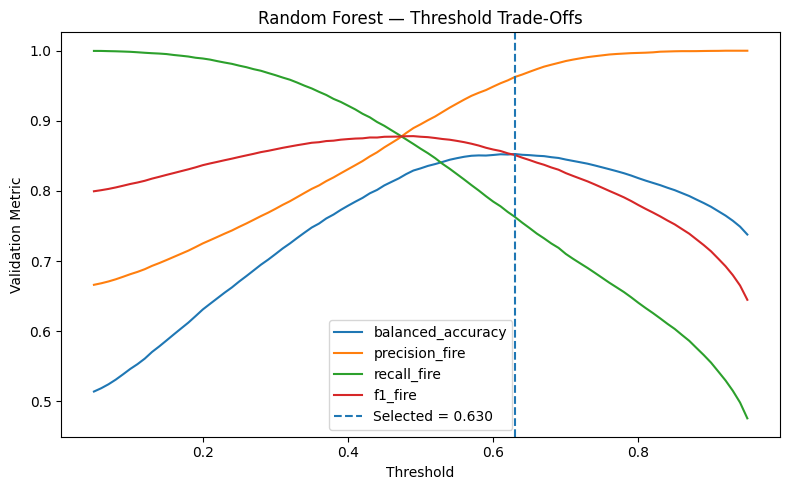

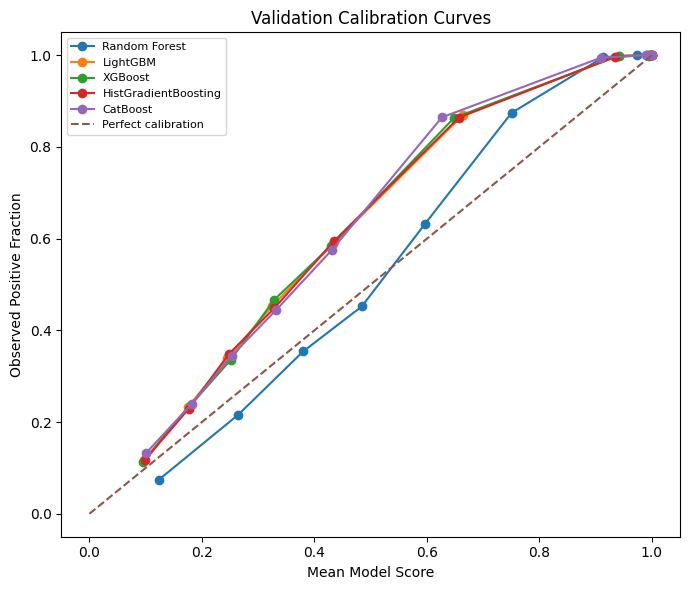

,model,brier_score,log_loss
0,Random Forest,0.1080,0.3328
1,LightGBM,0.1195,0.3553
2,HistGradientBoosting,0.1203,0.3578
3,XGBoost,0.1203,0.3567
4,CatBoost,0.1234,0.3673


In [15]:
# ==============================================================================
# THRESHOLD IMPROVEMENT CHECK
# ==============================================================================
threshold_comparison_rows = []

# Compare 0.50 against each model's validation-selected threshold
for name, model in fitted_models.items():
    if name == 'Dummy':
        continue

    scores = model.predict_proba(X_val)[:, 1]
    tuned_threshold = float(
        validation_results.loc[validation_results['model'] == name, 'threshold'].iloc[0]
    )

    default_metrics = evaluate_scores(y_val, scores, 0.50)
    tuned_metrics = evaluate_scores(y_val, scores, tuned_threshold)

    threshold_comparison_rows.append({
        'model': name,
        'balanced_accuracy_at_0.50': default_metrics['balanced_accuracy'],
        'balanced_accuracy_tuned': tuned_metrics['balanced_accuracy'],
        'f1_at_0.50': default_metrics['f1_fire'],
        'f1_tuned': tuned_metrics['f1_fire'],
        'selected_threshold': tuned_threshold
    })

threshold_comparison = pd.DataFrame(threshold_comparison_rows).sort_values(
    'balanced_accuracy_tuned', ascending=False
)
display(threshold_comparison.round(4))
threshold_comparison.to_csv(OUT_DIR / 'threshold_improvement.csv', index=False)

trade_name = (
    validation_results[validation_results['model'] != 'Dummy']
    .iloc[0]['model']
)

trade_threshold = float(
    validation_results.loc[
        validation_results['model'] == trade_name,
        'threshold'
    ].iloc[0]
)

trade_scores = fitted_models[trade_name].predict_proba(X_val)[:, 1]

threshold_grid = np.unique(
    np.r_[np.linspace(0.05, 0.95, 91), trade_threshold]
)

threshold_curve = pd.DataFrame([
    evaluate_scores(y_val, trade_scores, threshold)
    for threshold in threshold_grid
])

fig, ax = plt.subplots(figsize=(8, 5))

for metric in [
    'balanced_accuracy',
    'precision_fire',
    'recall_fire',
    'f1_fire'
]:
    ax.plot(
        threshold_curve['threshold'],
        threshold_curve[metric],
        label=metric
    )

ax.axvline(
    trade_threshold,
    linestyle='--',
    label=f'Selected = {trade_threshold:.3f}'
)

ax.set_xlabel('Threshold')
ax.set_ylabel('Validation Metric')
ax.set_title(f'{trade_name} — Threshold Trade-Offs')
ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'threshold_tradeoff_curve.png', dpi=180)
plt.show()

top_names = (
    validation_results[validation_results['model'] != 'Dummy']
    ['model']
    .head(5)
    .tolist()
)

calibration_rows = []
reliability_rows = []

fig, ax = plt.subplots(figsize=(7, 6))

for name in top_names:
    scores = fitted_models[name].predict_proba(X_val)[:, 1]

    observed, predicted = calibration_curve(
        y_val,
        scores,
        n_bins=10,
        strategy='quantile'
    )

    ax.plot(predicted, observed, marker='o', label=name)

    calibration_rows.append({
        'model': name,
        'brier_score': brier_score_loss(y_val, scores),
        'log_loss': log_loss(y_val, scores, labels=[0, 1])
    })

    for i, (predicted_score, observed_fraction) in enumerate(
        zip(predicted, observed)
    ):
        reliability_rows.append({
            'model': name,
            'bin': i + 1,
            'mean_score': predicted_score,
            'observed_fraction': observed_fraction
        })

ax.plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')
ax.set_xlabel('Mean Model Score')
ax.set_ylabel('Observed Positive Fraction')
ax.set_title('Validation Calibration Curves')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'calibration_curves.png', dpi=180)
plt.show()

calibration_results = pd.DataFrame(calibration_rows).sort_values(
    'brier_score'
).reset_index(drop=True)

display(calibration_results.round(4))

calibration_results.to_csv(
    OUT_DIR / 'calibration_metrics.csv',
    index=False
)

pd.DataFrame(reliability_rows).to_csv(
    OUT_DIR / 'calibration_bins.csv',
    index=False
)


## 10. FINAL TEST EVALUATION

Selects the best real model from validation results, then evaluates it once on the untouched test set.


In [16]:
# ==============================================================================
# SELECT MODEL + FINAL TEST
# ==============================================================================
# Dummy is a benchmark only; select the best trained classifier
real_models = validation_results[validation_results['model'] != 'Dummy'].copy()
best_name = real_models.iloc[0]['model']
best_threshold = float(real_models.iloc[0]['threshold'])
best_model = fitted_models[best_name]

print('Selected model:', best_name)
print('Selected threshold:', round(best_threshold, 4))

# Test set is touched only after model + threshold are fixed
test_scores = best_model.predict_proba(X_test)[:, 1]
test_metrics = evaluate_scores(y_test, test_scores, best_threshold)

test_results = pd.DataFrame([{'model': best_name, **test_metrics}])
display(test_results.round(4))
test_results.to_csv(OUT_DIR / 'final_test_metrics.csv', index=False)


Selected model: Random Forest
Selected threshold: 0.6299


,model,threshold,accuracy,balanced_accuracy,precision_fire,recall_fire,f1_fire,roc_auc,pr_auc,tn,fp,fn,tp
0,Random Forest,0.6299,0.8265,0.8555,0.965,0.7648,0.8533,0.9274,0.9662,12677,720,6111,19867


## 11. EVALUATION CURVES

Confusion matrix, ROC curve and Precision–Recall curve for the selected model.


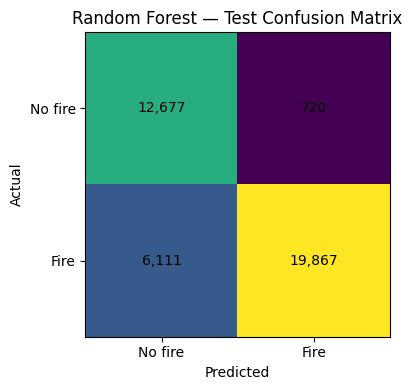

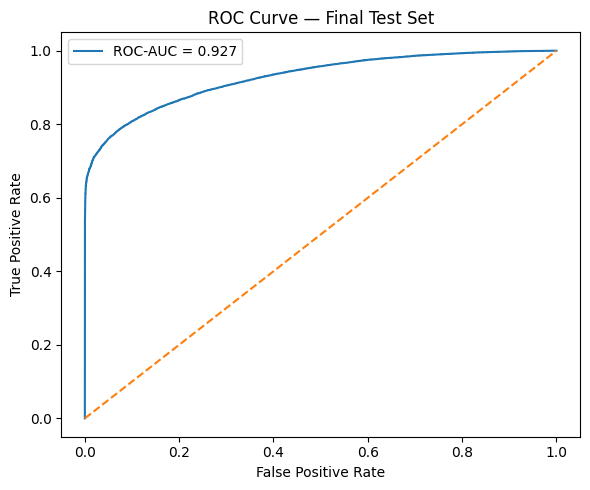

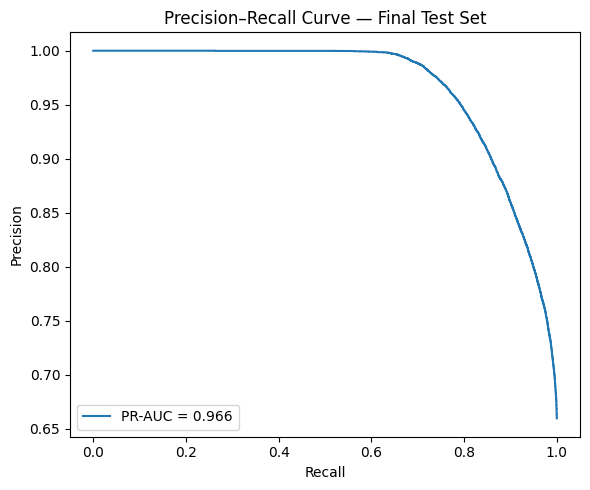

In [17]:
# ==============================================================================
# CONFUSION MATRIX + ROC / PR CURVES
# ==============================================================================
# ---- 1. Confusion matrix ----
test_pred = (test_scores >= best_threshold).astype(int)
cm = confusion_matrix(y_test, test_pred)

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm)
for (i, j), value in np.ndenumerate(cm):
    ax.text(j, i, f'{value:,}', ha='center', va='center')
ax.set_xticks([0, 1], ['No fire', 'Fire'])
ax.set_yticks([0, 1], ['No fire', 'Fire'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'{best_name} — Test Confusion Matrix')
plt.tight_layout()
plt.savefig(OUT_DIR / 'confusion_matrix.png', dpi=180)
plt.show()

# ---- 2. ROC curve ----
fpr, tpr, _ = roc_curve(y_test, test_scores)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_score(y_test, test_scores):.3f}')
ax.plot([0, 1], [0, 1], linestyle='--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Final Test Set')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'roc_curve.png', dpi=180)
plt.show()

# ---- 3. Precision-Recall curve ----
precision, recall, _ = precision_recall_curve(y_test, test_scores)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall, precision, label=f'PR-AUC = {average_precision_score(y_test, test_scores):.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision–Recall Curve — Final Test Set')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'precision_recall_curve.png', dpi=180)
plt.show()


## 12. FEATURE IMPORTANCE + SHAP

Native feature importance is shown for supported tree models. SHAP is also used on a validation sample to show which predictors push the selected model's fire score higher or lower.

These values explain model behaviour; they do not prove causation.


,feature,importance
11,et0_fao_evapotranspiration,0.302952
15,emc,0.055289
10,vapour_pressure_deficit,0.054966
3,relative_humidity_2m,0.053822
2,temperature_2m,0.045445
18,day_of_year_cos,0.044987
7,wind_direction_cos,0.041390
16,ffdi,0.039151
4,wind_speed_10m,0.037110
8,precipitation,0.035671


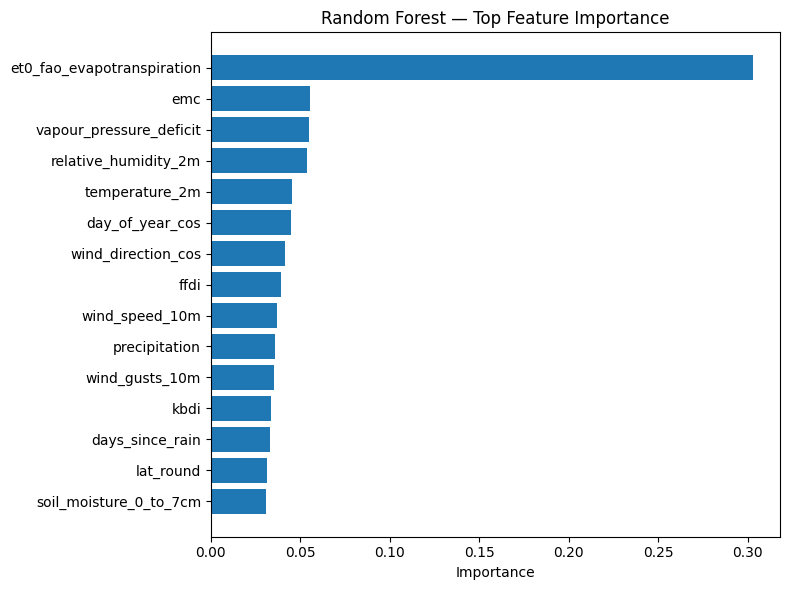

PermutationExplainer explainer: 101it [00:35,  2.53it/s]


,feature,mean_absolute_shap
0,et0_fao_evapotranspiration,0.145840
1,precipitation,0.030037
2,day_of_year_cos,0.019385
3,emc,0.018995
4,relative_humidity_2m,0.016682
5,days_since_rain,0.016359
6,vapour_pressure_deficit,0.014833
7,temperature_2m,0.013548
8,wind_direction_cos,0.012106
9,kbdi,0.011850


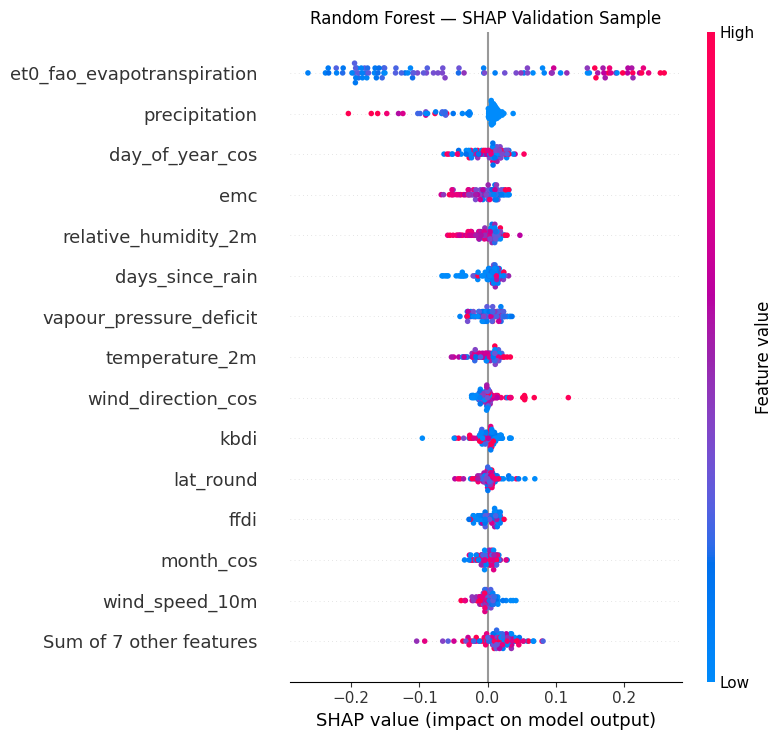

In [18]:
# ==============================================================================
# FEATURE IMPORTANCE
# ==============================================================================
# Tree models expose feature_importances_; linear baseline does not
if hasattr(best_model, 'feature_importances_'):
    importance = pd.DataFrame({
        'feature': FEATURES,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)

    display(importance.head(15))
    importance.to_csv(OUT_DIR / 'feature_importance.csv', index=False)

    top = importance.head(15).sort_values('importance')
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top['feature'], top['importance'])
    ax.set_xlabel('Importance')
    ax.set_title(f'{best_name} — Top Feature Importance')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'feature_importance.png', dpi=180)
    plt.show()
else:
    print('Native feature importance is not available for the selected model.')

background = X_train.sample(
    min(SHAP_BACKGROUND_ROWS, len(X_train)),
    random_state=RANDOM_STATE
)

X_shap = X_val.sample(
    min(SHAP_ROWS, len(X_val)),
    random_state=RANDOM_STATE
)

def predict_for_shap(values):
    frame = pd.DataFrame(values, columns=FEATURES)
    return best_model.predict_proba(frame)[:, 1]

explainer = shap.Explainer(
    predict_for_shap,
    background,
    algorithm='permutation',
    feature_names=FEATURES,
    seed=RANDOM_STATE
)

shap_values = explainer(
    X_shap,
    max_evals=3 * (2 * len(FEATURES) + 1)
)

shap_importance = pd.DataFrame({
    'feature': FEATURES,
    'mean_absolute_shap': np.abs(shap_values.values).mean(axis=0)
}).sort_values(
    'mean_absolute_shap',
    ascending=False
).reset_index(drop=True)

display(shap_importance.head(15))

shap_importance.to_csv(
    OUT_DIR / 'shap_global_importance.csv',
    index=False
)

pd.DataFrame(
    shap_values.values,
    columns=FEATURES,
    index=X_shap.index
).to_csv(
    OUT_DIR / 'shap_values.csv',
    index_label='source_row'
)

shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=False
)

plt.title(f'{best_name} — SHAP Validation Sample')
plt.tight_layout()
plt.savefig(
    OUT_DIR / 'shap_summary.png',
    dpi=180,
    bbox_inches='tight'
)
plt.show()



## 13. TEST PREDICTIONS + ERROR ANALYSIS

Stores row-level fire-risk scores and predicted labels, then compares false positives and false negatives with correctly classified observations. Monthly and grid-cell summaries are also saved for later checking.


In [19]:
# ==============================================================================
# SAVE ROW-LEVEL TEST PREDICTIONS
# ==============================================================================
# Keep date/location + ground truth next to the score for error analysis
prediction_output = df.loc[X_test.index, ['acq_date', 'lat_round', 'lon_round', 'label']].copy()
prediction_output['fire_risk_score'] = test_scores
prediction_output['fire_risk_percent'] = 100 * test_scores
prediction_output['predicted_label'] = test_pred

prediction_output.to_csv(OUT_DIR / 'test_predictions.csv', index=False)
display(prediction_output.head(10))

error_output = prediction_output.copy()

error_output['error_type'] = np.select(
    [
        (y_test == 1) & (test_pred == 1),
        (y_test == 0) & (test_pred == 0),
        (y_test == 0) & (test_pred == 1)
    ],
    ['TP', 'TN', 'FP'],
    default='FN'
)

error_output.to_csv(
    OUT_DIR / 'test_predictions_with_errors.csv',
    index_label='source_row'
)

# ---- 1. Feature profiles ----
error_features = X_test.copy()
error_features['error_type'] = error_output['error_type']

error_profile = (
    error_features
    .groupby('error_type')[FEATURES]
    .mean()
    .reindex(['TN', 'FP', 'TP', 'FN'])
    .T
)

error_profile['overall_mean'] = X_test.mean()
error_profile['FP_minus_TN'] = error_profile['FP'] - error_profile['TN']
error_profile['FN_minus_TP'] = error_profile['FN'] - error_profile['TP']

display(error_profile.round(3))

error_profile.to_csv(
    OUT_DIR / 'error_feature_profiles.csv',
    index_label='feature'
)

# ---- 2. Monthly + grid summaries ----
summary_input = error_output.copy()
summary_input['month'] = pd.to_datetime(
    summary_input['acq_date']
).dt.month

for label_name in ['TP', 'TN', 'FP', 'FN']:
    summary_input[label_name] = (
        summary_input['error_type'] == label_name
    ).astype(int)

def build_error_summary(keys):
    result = summary_input.groupby(keys)[
        ['TP', 'TN', 'FP', 'FN']
    ].sum()

    result['n'] = result[
        ['TP', 'TN', 'FP', 'FN']
    ].sum(axis=1)

    result['positive_n'] = result['TP'] + result['FN']
    result['negative_n'] = result['TN'] + result['FP']

    result['false_negative_rate'] = (
        result['FN'] /
        result['positive_n'].replace(0, np.nan)
    )

    result['false_positive_rate'] = (
        result['FP'] /
        result['negative_n'].replace(0, np.nan)
    )

    return result

monthly_errors = build_error_summary(['month'])
spatial_errors = build_error_summary(
    ['lat_round', 'lon_round']
)

monthly_errors.to_csv(
    OUT_DIR / 'errors_by_month.csv'
)

spatial_errors.to_csv(
    OUT_DIR / 'errors_by_grid_cell.csv'
)

display(monthly_errors.round(4))

print(
    f"Missed {test_metrics['fn']:,} of "
    f"{int(y_test.sum()):,} positive test cases."
)


,acq_date,lat_round,lon_round,label,fire_risk_score,fire_risk_percent,predicted_label
60742,2026-03-30,-30.0,148.5,1,0.511245,51.124499,0
205562,2024-11-15,-12.0,134.0,0,0.371541,37.154138,0
130826,2024-11-01,-19.5,128.0,1,0.972320,97.231954,1
146325,2024-10-09,-18.0,145.5,1,0.472646,47.264581,0
68712,2025-05-04,-28.5,114.5,0,0.213057,21.305710,0
10925,2024-05-01,-37.0,150.0,0,0.178800,17.879991,0
109719,2026-06-20,-22.5,117.0,0,0.294254,29.425416,0
113876,2025-10-20,-22.0,120.5,1,0.728981,72.898062,1
141038,2025-12-15,-18.5,140.5,1,0.361148,36.114763,0
75648,2025-01-11,-27.5,149.0,0,0.178581,17.858138,0


error_type,TN,FP,TP,FN,overall_mean,FP_minus_TN,FN_minus_TP
lat_round,-24.637,-24.561,-23.251,-25.296,-24.039,0.076,-2.046
lon_round,139.740,137.691,138.693,140.128,139.235,-2.049,1.435
temperature_2m,20.293,24.018,24.875,20.663,22.730,3.725,-4.211
relative_humidity_2m,63.553,46.445,47.709,60.581,54.785,-17.108,12.872
wind_speed_10m,11.886,14.125,12.449,11.689,12.181,2.239,-0.761
wind_gusts_10m,24.350,27.181,27.052,23.985,25.708,2.831,-3.067
wind_direction_sin,0.315,0.312,0.336,0.323,0.327,-0.003,-0.013
wind_direction_cos,-0.437,-0.250,-0.173,-0.432,-0.300,0.187,-0.258
precipitation,1.530,0.140,0.369,0.891,0.820,-1.390,0.522
soil_moisture_0_to_7cm,0.189,0.135,0.155,0.183,0.170,-0.053,0.028


,TP,TN,FP,FN,n,positive_n,negative_n,false_negative_rate,false_positive_rate
month,,,,,,,,,
1,961,558,52,305,1876,1266,610,0.2409,0.0852
2,666,474,26,255,1421,921,500,0.2769,0.0520
3,1015,642,30,389,2076,1404,672,0.2771,0.0446
4,2720,1145,123,751,4739,3471,1268,0.2164,0.0970
5,1913,1873,31,748,4565,2661,1904,0.2811,0.0163
6,1380,1730,20,629,3759,2009,1750,0.3131,0.0114
7,1351,1637,18,535,3541,1886,1655,0.2837,0.0109
8,2004,1553,39,627,4223,2631,1592,0.2383,0.0245
9,2077,744,130,492,3443,2569,874,0.1915,0.1487


Missed 6,111 of 25,978 positive test cases.


## 14. SAVE PRODUCTION MODEL + RUN METADATA

The selected model is first saved in its evaluated form using the model fitted on the training split. This is the exact model used to generate the held-out test results reported in this notebook.

A second copy of the selected model configuration is then refitted using all available labelled data for deployment. The production refit is kept separate because the held-out test data is included during refitting, so its performance should not be represented by the previously reported test metrics.

In [22]:
# ==============================================================================
# SAVE EVALUATED MODEL
# ==============================================================================

# This is the exact model used for the held-out test evaluation
evaluated_bundle = {
    'model': best_model,
    'model_name': best_name,
    'threshold': best_threshold,
    'features': FEATURES,
    'target': 'label',
    'fit_scope': 'training_split',
    'test_metrics': test_metrics
}

evaluated_model_path = OUT_DIR / 'fire_occurrence_model_evaluated.pkl'

joblib.dump(
    evaluated_bundle,
    evaluated_model_path
)

print('Saved evaluated model:', evaluated_model_path)

Saved evaluated model: /content/drive/MyDrive/fire_model_outputs/fire_occurrence_model_evaluated.pkl


In [23]:
# ==============================================================================
# REFIT + SAVE PRODUCTION MODEL
# ==============================================================================
# Refit the selected model configuration using all labelled data
# This model is intended for deployment, not for reporting test performance
production_model = clone(models[best_name])
production_model.fit(X, y)

model_bundle = {
    'model': production_model,
    'model_name': best_name,
    'threshold': best_threshold,
    'features': FEATURES,
    'target': 'label',
    'target_definition': (
        '1 = fire occurrence / qualifying detection; '
        '0 = sampled no-fire day'
    ),
    'fit_scope': 'all_labelled_rows',
    'score_note': (
        'predict_proba output is a model fire-risk score; '
        'validate calibration before treating it as a literal '
        'real-world probability'
    )
}

model_path = OUT_DIR / 'fire_occurrence_model.pkl'

joblib.dump(
    model_bundle,
    model_path
)

print('Saved production model:', model_path)

# ---- 1. Reload check ----
reloaded_bundle = joblib.load(model_path)

reload_sample = X_test.iloc[:20]

expected_scores = production_model.predict_proba(
    reload_sample
)[:, 1]

reloaded_scores = reloaded_bundle['model'].predict_proba(
    reload_sample
)[:, 1]

np.testing.assert_allclose(
    expected_scores,
    reloaded_scores
)

print('Reload check passed:', model_path)

# ---- 2. Save experiment metadata ----
package_names = [
    'numpy',
    'pandas',
    'scikit-learn',
    'imbalanced-learn',
    'xgboost',
    'lightgbm',
    'catboost',
    'shap',
    'joblib'
]

package_versions = {}

for package_name in package_names:
    try:
        package_versions[package_name] = version(package_name)
    except Exception:
        package_versions[package_name] = 'unknown'

test_metrics_json = {}

for key, value in test_metrics.items():
    if isinstance(value, (np.integer,)):
        test_metrics_json[key] = int(value)
    elif isinstance(value, (np.floating,)):
        test_metrics_json[key] = float(value)
    else:
        test_metrics_json[key] = value

experiment_metadata = {
    'model_name': best_name,
    'threshold': float(best_threshold),
    'threshold_method': 'validation Youden J / balanced accuracy',
    'features': FEATURES,
    'feature_count': len(FEATURES),
    'rows': len(X),
    'train_rows': len(X_train),
    'validation_rows': len(X_val),
    'test_rows': len(X_test),
    'cv_rows': len(X_cv),
    'cv_folds': CV_FOLDS,
    'random_state': RANDOM_STATE,
    'date_min': str(df['acq_date'].min()),
    'date_max': str(df['acq_date'].max()),
    'python': platform.python_version(),
    'packages': package_versions,
    'test_metrics': test_metrics_json
}

with open(
    OUT_DIR / 'experiment_metadata.json',
    'w'
) as file:
    json.dump(
        experiment_metadata,
        file,
        indent=2
    )

with open(
    OUT_DIR / 'requirements_run.txt',
    'w'
) as file:
    file.write(
        '\n'.join(
            f'{name}=={value}'
            for name, value in package_versions.items()
        ) + '\n'
    )

print('Saved experiment metadata.')


Saved production model: /content/drive/MyDrive/fire_model_outputs/fire_occurrence_model.pkl
Reload check passed: /content/drive/MyDrive/fire_model_outputs/fire_occurrence_model.pkl
Saved experiment metadata.


## 15. FINAL RESULTS

The selected model, validation-selected threshold, held-out test metrics and cross-validation setup from the current run are shown below.


In [24]:
# ==============================================================================
# FINAL RESULTS
# ==============================================================================
print('Selected model:', best_name)
print('Validation-selected threshold:', round(best_threshold, 4))
display(test_results.round(4))

print('Cross-validation rows:', len(X_cv))
print('Cross-validation folds:', CV_FOLDS)
print('Output folder:', OUT_DIR)

Selected model: Random Forest
Validation-selected threshold: 0.6299


,model,threshold,accuracy,balanced_accuracy,precision_fire,recall_fire,f1_fire,roc_auc,pr_auc,tn,fp,fn,tp
0,Random Forest,0.6299,0.8265,0.8555,0.965,0.7648,0.8533,0.9274,0.9662,12677,720,6111,19867


Cross-validation rows: 25000
Cross-validation folds: 3
Output folder: /content/drive/MyDrive/fire_model_outputs


## 16. FINAL OUTPUT GOOGLE DRIVE LINK
https://drive.google.com/drive/folders/1lWqxXasX5FrOV85-xN4KAlA6pO9wV1wW?usp=sharing